# Reversible Multipliers with Oscillators

This notebook demonstrates the synthesis and operation of reversible multiplier circuits using coupled oscillators. We'll cover:
1. Creating multiplier netlists with logic gates
2. Querying the synthesizer for oscillator implementations
3. Connecting oscillators to form complete multipliers
4. Testing forward multiplication via ODE solving
5. Testing backward factorization of semiprimes

## 1. Import Required Libraries

In [1]:
import sys

sys.path.insert(0, "/home/wyn/Ark")

import numpy as np
import matplotlib.pyplot as plt
from itertools import product
from scipy.integrate import solve_ivp, odeint
import jax
import jax.numpy as jnp
import diffrax
import lineax
from obc_syn import (
    synthesize_general,
    rectify_phases,
    phase_to_bool,
)

jax.config.update("jax_enable_x64", True)
np.random.seed(428)

## 2. Create Multiplier Netlists with Logic Gates

We'll build 2-bit multiplier circuits. A 2-bit multiplier computes the product of two 2-bit numbers.
- Inputs: a[0], a[1], b[0], b[1] (two 2-bit numbers)
- Output: p[0], p[1], p[2], p[3] (4-bit product, up to 9)

The multiplier is constructed from AND gates and full adders.

In [2]:
class SimpleMultiplier:
    """2-bit x 2-bit = 4-bit reversible multiplier using logic gates"""

    def __init__(self):
        self.gates = {}  # Will store synthesized gate matrices

    def create_netlist(self):
        """Create the logical netlist for 2x2 multiplier"""
        self.netlist = {
            "inputs": ["a0", "a1", "b0", "b1"],
            "outputs": ["p0", "p1", "p2", "p3"],
            "gates": [],
        }

        # Partial products (AND gates)
        # p_row0: a[0] & b[0:2]
        self.netlist["gates"].append(
            {"type": "AND", "inputs": ["a0", "b0"], "output": "pp00"}
        )
        self.netlist["gates"].append(
            {"type": "AND", "inputs": ["a0", "b1"], "output": "pp01"}
        )

        # p_row1: a[1] & b[0:2]
        self.netlist["gates"].append(
            {"type": "AND", "inputs": ["a1", "b0"], "output": "pp10"}
        )
        self.netlist["gates"].append(
            {"type": "AND", "inputs": ["a1", "b1"], "output": "pp11"}
        )

        # Adders for bit 0 (pp00 is p0)
        # Bit 1: pp01 + pp10
        self.netlist["gates"].append(
            {"type": "XOR", "inputs": ["pp01", "pp10"], "output": "p1"}
        )
        self.netlist["gates"].append(
            {"type": "AND", "inputs": ["pp01", "pp10"], "output": "c1"}
        )

        # Bit 2: pp11 + c1
        self.netlist["gates"].append(
            {"type": "XOR", "inputs": ["pp11", "c1"], "output": "p2"}
        )
        self.netlist["gates"].append(
            {"type": "AND", "inputs": ["pp11", "c1"], "output": "p3"}
        )

        return self.netlist

    def truth_table_mult(self, a, b):
        """Compute truth table: output for given inputs (0-3 for 2-bit)"""
        product = a * b
        return [(product >> i) & 1 for i in range(4)]

    def logic_function_2bit_mult(self, a0, a1, b0, b1):
        """Full logic function for 2-bit multiplier"""
        pp00 = a0 & b0
        pp01 = a0 & b1
        pp10 = a1 & b0
        pp11 = a1 & b1

        p0 = pp00
        p1 = pp01 ^ pp10
        c1 = pp01 & pp10
        p2 = pp11 ^ c1
        p3 = pp11 & c1

        return p0, p1, p2, p3


mult = SimpleMultiplier()
netlist = mult.create_netlist()
print("2x2 Multiplier Netlist:")
for gate in netlist["gates"]:
    print(f"  {gate['output']} = {gate['type']}({', '.join(gate['inputs'])})")
print(f"\nInputs: {netlist['inputs']}")
print(f"Outputs: {netlist['outputs']}")

2x2 Multiplier Netlist:
  pp00 = AND(a0, b0)
  pp01 = AND(a0, b1)
  pp10 = AND(a1, b0)
  pp11 = AND(a1, b1)
  p1 = XOR(pp01, pp10)
  c1 = AND(pp01, pp10)
  p2 = XOR(pp11, c1)
  p3 = AND(pp11, c1)

Inputs: ['a0', 'a1', 'b0', 'b1']
Outputs: ['p0', 'p1', 'p2', 'p3']


## 3. Query Synthesizer for Oscillator Gate Implementations

We'll synthesize the required logic gates (AND, XOR) into oscillator coupling matrices.

In [3]:
def synthesize_gates(verbose=True):
    """Synthesize required gates: AND, XOR"""
    gates_to_synthesize = {
        "AND": [lambda x, y, z: (x & y) == z, 3, 0],
        "XOR": [lambda x, y, z: (x ^ y) == z, 3, 1],
    }

    synthesized_gates = {}
    for gate_name, [gate_func, n_io_var, n_aux_osc] in gates_to_synthesize.items():
        if verbose:
            print(f"\nSynthesizing {gate_name}...")

        J_mat = synthesize_general(
            gate_func,
            n_io_var=n_io_var,
            n_aux_osc=n_aux_osc,
            symmetric=True,
            constrain_coupling=0,
            constrain_energy_threshold=False,
        )

        if J_mat is not None:
            synthesized_gates[gate_name] = {
                "J_matrix": J_mat,
                "n_io_var": n_io_var,
                "n_aux_osc": n_aux_osc,
                "n_osc_total": n_io_var + n_aux_osc + 1,  # +1 for reference
            }
            if verbose:
                print(f"  ✓ Synthesis successful")
                print(f"  Oscillators: {synthesized_gates[gate_name]['n_osc_total']}")
                print(f"  Coupling matrix shape: {J_mat.shape}")
        else:
            print(f"  ✗ Synthesis failed for {gate_name}")

    return synthesized_gates


print("Synthesizing logic gates...")
synthesized_gates = synthesize_gates(verbose=True)
print(f"\nSuccessfully synthesized {len(synthesized_gates)} gates")

Synthesizing logic gates...

Synthesizing AND...
  ✓ Synthesis successful
  Oscillators: 4
  Coupling matrix shape: (4, 4)

Synthesizing XOR...
  ✓ Synthesis successful
  Oscillators: 5
  Coupling matrix shape: (5, 5)

Successfully synthesized 2 gates


In [4]:
# Display the coupling matrices
for gate_name, gate_info in synthesized_gates.items():
    print(f"\n{gate_name} Coupling Matrix:")
    print(gate_info["J_matrix"])


AND Coupling Matrix:
[[ 0  1 -2 -1]
 [ 1  0 -2 -1]
 [-2 -2  0  2]
 [-1 -1  2  0]]

XOR Coupling Matrix:
[[ 0  1 -1 -2 -1]
 [ 1  0 -1 -2 -1]
 [-1 -1  0  2  1]
 [-2 -2  2  0  2]
 [-1 -1  1  2  0]]


## 4. Connect Oscillator Gates to Form a Multiplier

We'll assemble the oscillator gates into a complete 2x2 multiplier circuit by connecting their outputs to inputs of subsequent gates.

In [5]:
class OscillatorMultiplier:
    """Assembled oscillator-based multiplier from synthesized gates with shared reference"""

    def __init__(self, synthesized_gates):
        self.synthesized_gates = synthesized_gates
        self.J_full = None
        self.n_osc_total = 0
        self.osc_names = {}  # Maps oscillator names to indices
        self.gates_config = []  # List of gate configurations
        self.build_multiplier()

    def build_multiplier(self):
        """Assemble the full coupled oscillator system with shared reference and output reuse"""
        # Circuit: 2x2 bit multiplier
        # Shared reference oscillator at fixed phase (π)
        # Inputs: a0, a1, b0, b1
        # Partial products via AND gates: pp00, pp01, pp10, pp11
        # Final outputs via additional gates: p0, p1, p2, p3

        osc_idx = 0
        self.osc_names = {}

        # 1. Input oscillators (a0, a1, b0, b1)
        input_names = ["a0", "a1", "b0", "b1"]
        self.input_indices = {}
        for name in input_names:
            self.osc_names[name] = osc_idx
            self.input_indices[name] = osc_idx
            osc_idx += 1

        # 2. Shared reference oscillator (same for all gates)
        self.ref_idx = osc_idx
        self.osc_names["ref"] = self.ref_idx
        osc_idx += 1

        # 3. Allocate oscillators for gates with output reuse
        # AND gates: [input0, input1, output, ref] - NO auxiliary oscillator
        # XOR gates: [input0, input1, output, aux, ref] - 1 auxiliary oscillator

        # pp00 = a0 & b0 (AND gate - no aux)
        self.osc_names["pp00"] = osc_idx
        osc_idx += 1

        # pp01 = a0 & b1 (AND gate - no aux)
        self.osc_names["pp01"] = osc_idx
        osc_idx += 1

        # pp10 = a1 & b0 (AND gate - no aux)
        self.osc_names["pp10"] = osc_idx
        osc_idx += 1

        # pp11 = a1 & b1 (AND gate - no aux)
        self.osc_names["pp11"] = osc_idx
        osc_idx += 1

        # p0 = pp00 (direct, no new oscillator)
        self.osc_names["p0"] = self.osc_names["pp00"]

        # p1 = pp01 ^ pp10 (XOR gate - needs aux)
        self.osc_names["p1"] = osc_idx
        osc_idx += 1
        self.osc_names["p1_aux"] = osc_idx
        osc_idx += 1

        # c1 = pp01 & pp10 (AND gate - no aux)
        self.osc_names["c1"] = osc_idx
        osc_idx += 1

        # p2 = pp11 ^ c1 (XOR gate - needs aux)
        self.osc_names["p2"] = osc_idx
        osc_idx += 1
        self.osc_names["p2_aux"] = osc_idx
        osc_idx += 1

        # p3 = pp11 & c1 (AND gate - no aux)
        self.osc_names["p3"] = osc_idx
        osc_idx += 1

        self.n_osc_total = osc_idx
        self.J_full = np.zeros((self.n_osc_total, self.n_osc_total))

        # Build gate configurations: [gate_type, inputs, output, aux, ref]
        # For AND gates, aux=None (not used)
        # For XOR gates, aux is the auxiliary oscillator index
        self.gates_config = [
            (
                "AND",
                [self.input_indices["a0"], self.input_indices["b0"]],
                self.osc_names["pp00"],
                None,
                self.ref_idx,
            ),
            (
                "AND",
                [self.input_indices["a0"], self.input_indices["b1"]],
                self.osc_names["pp01"],
                None,
                self.ref_idx,
            ),
            (
                "AND",
                [self.input_indices["a1"], self.input_indices["b0"]],
                self.osc_names["pp10"],
                None,
                self.ref_idx,
            ),
            (
                "AND",
                [self.input_indices["a1"], self.input_indices["b1"]],
                self.osc_names["pp11"],
                None,
                self.ref_idx,
            ),
            (
                "XOR",
                [self.osc_names["pp01"], self.osc_names["pp10"]],
                self.osc_names["p1"],
                self.osc_names["p1_aux"],
                self.ref_idx,
            ),
            (
                "AND",
                [self.osc_names["pp01"], self.osc_names["pp10"]],
                self.osc_names["c1"],
                None,
                self.ref_idx,
            ),
            (
                "XOR",
                [self.osc_names["pp11"], self.osc_names["c1"]],
                self.osc_names["p2"],
                self.osc_names["p2_aux"],
                self.ref_idx,
            ),
            (
                "AND",
                [self.osc_names["pp11"], self.osc_names["c1"]],
                self.osc_names["p3"],
                None,
                self.ref_idx,
            ),
        ]

        # Compose full coupling matrix from gates
        self._assemble_coupling_matrix()

        print(f"Built oscillator multiplier with {self.n_osc_total} oscillators")
        print(f"Coupling matrix shape: {self.J_full.shape}")
        print(f"Shared reference oscillator at index: {self.ref_idx}")
        print(f"Gate configurations:")
        for i, (gtype, inputs, output, aux, ref) in enumerate(self.gates_config):
            print(
                f"  Gate {i+1} ({gtype}): inputs={inputs}, output={output}, aux={aux}, ref={ref}"
            )

    def _assemble_coupling_matrix(self):
        """Assemble the full coupling matrix from individual gate matrices"""
        for gate_type, inputs, output, aux, ref in self.gates_config:
            if gate_type not in self.synthesized_gates:
                print(f"Warning: Gate type {gate_type} not synthesized, skipping")
                continue

            gate_info = self.synthesized_gates[gate_type]
            gate_J = gate_info["J_matrix"]
            n_aux = gate_info["n_aux_osc"]
            n_gate_osc = gate_J.shape[0]

            # Build local-to-global index mapping based on gate type
            # Structure: [input0, input1, output, ...aux_oscillators..., ref]
            local_indices = [inputs[0], inputs[1], output]

            # Add auxiliary oscillators only if they exist
            if n_aux > 0:
                local_indices.append(aux)

            # Add reference oscillator
            local_indices.append(ref)

            # Verify dimensions match
            assert (
                len(local_indices) == n_gate_osc
            ), f"{gate_type} gate: expected {n_gate_osc} oscillators, got {len(local_indices)}"

            # Place gate matrix into full matrix
            for i in range(n_gate_osc):
                for j in range(n_gate_osc):
                    global_i = local_indices[i]
                    global_j = local_indices[j]
                    self.J_full[global_i, global_j] += gate_J[i, j]

    def set_input_phases(self, a0, a1, b0, b1):
        """Set input phase values"""
        phases = np.ones(self.n_osc_total)
        phases[self.input_indices["a0"]] = a0 * np.pi
        phases[self.input_indices["a1"]] = a1 * np.pi
        phases[self.input_indices["b0"]] = b0 * np.pi
        phases[self.input_indices["b1"]] = b1 * np.pi
        phases[self.ref_idx] = np.pi  # Fixed reference at π
        return phases


osc_mult = OscillatorMultiplier(synthesized_gates)
print(f"\nOscillator multiplier initialized")
print(f"Total coupled oscillators: {osc_mult.n_osc_total}")

Built oscillator multiplier with 15 oscillators
Coupling matrix shape: (15, 15)
Shared reference oscillator at index: 4
Gate configurations:
  Gate 1 (AND): inputs=[0, 2], output=5, aux=None, ref=4
  Gate 2 (AND): inputs=[0, 3], output=6, aux=None, ref=4
  Gate 3 (AND): inputs=[1, 2], output=7, aux=None, ref=4
  Gate 4 (AND): inputs=[1, 3], output=8, aux=None, ref=4
  Gate 5 (XOR): inputs=[6, 7], output=9, aux=10, ref=4
  Gate 6 (AND): inputs=[6, 7], output=11, aux=None, ref=4
  Gate 7 (XOR): inputs=[8, 11], output=12, aux=13, ref=4
  Gate 8 (AND): inputs=[8, 11], output=14, aux=None, ref=4

Oscillator multiplier initialized
Total coupled oscillators: 15


## 5. Test Forward Functionality with ODE Solving

Test multiplication: Given input oscillator values, verify outputs converge to the product.

Testing forward multiplication with annealed locking...

Testing forward multiplication: [0, 0] × [0, 0] = ?
A = [0, 0] (0), B = [0, 0] (0)
Expected product: [0, 0, 0, 0] (0)
Annealing: Kl 0.1 → 2 over 50s
Fixed input indices: [0, 1, 2, 3, 4]

ODE integration completed. Timepoints: 502
Final output phases (rectified): [0. 0. 0. 0.]
Output bits: [0, 0, 0, 0]
Match expected: True


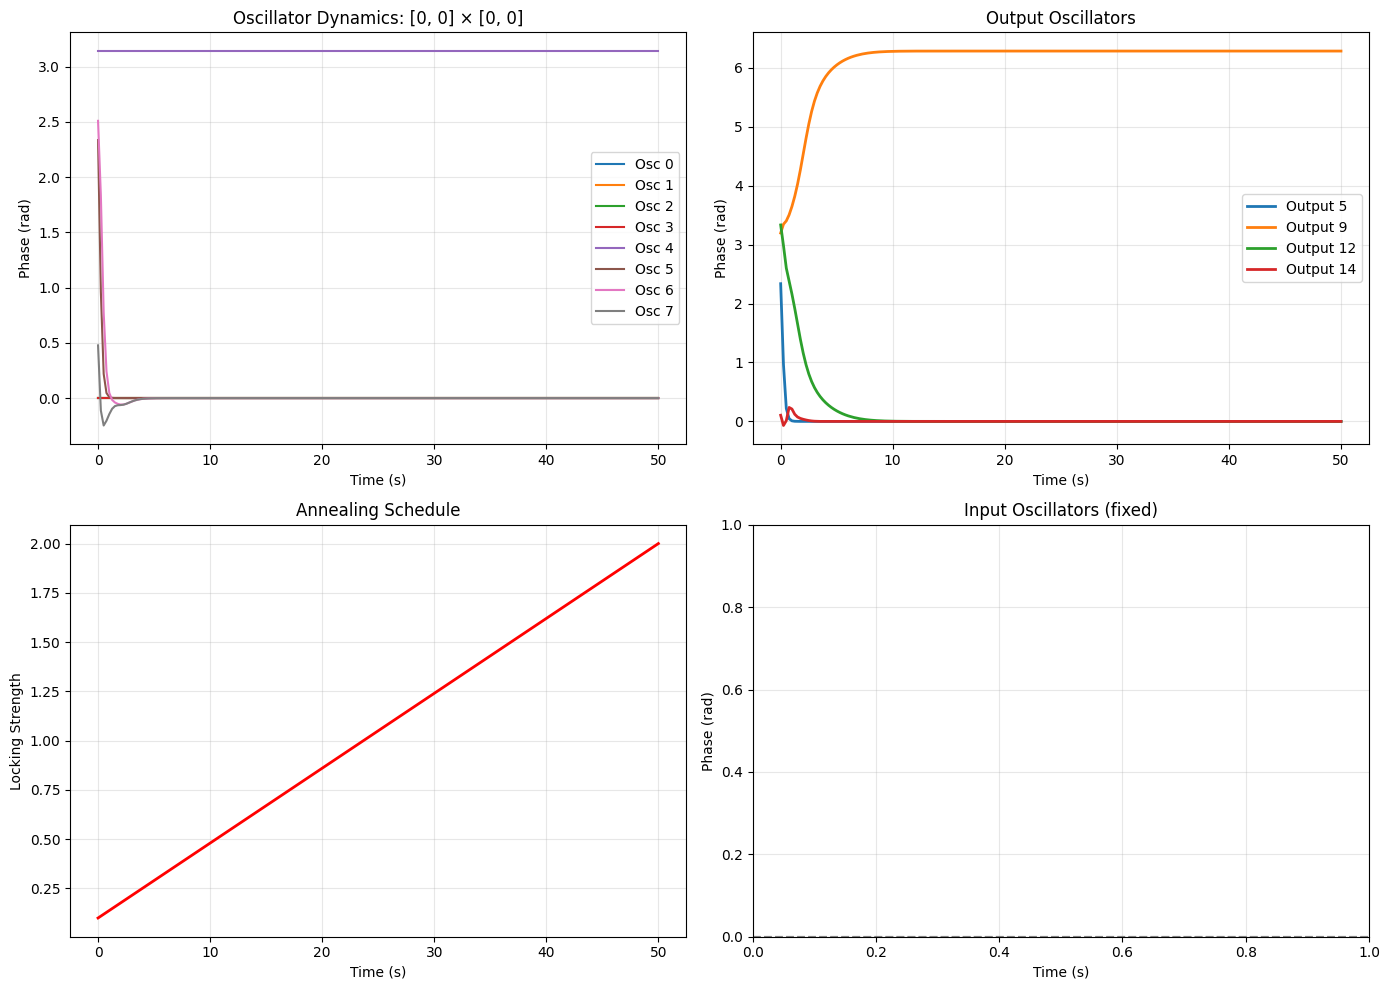


Testing forward multiplication: [1, 0] × [1, 0] = ?
A = [1, 0] (1), B = [1, 0] (1)
Expected product: [1, 0, 0, 0] (1)
Annealing: Kl 0.1 → 2 over 50s
Fixed input indices: [0, 1, 2, 3, 4]

ODE integration completed. Timepoints: 502
Final output phases (rectified): [3.14159265 0.         0.         0.        ]
Output bits: [1, 0, 0, 0]
Match expected: True


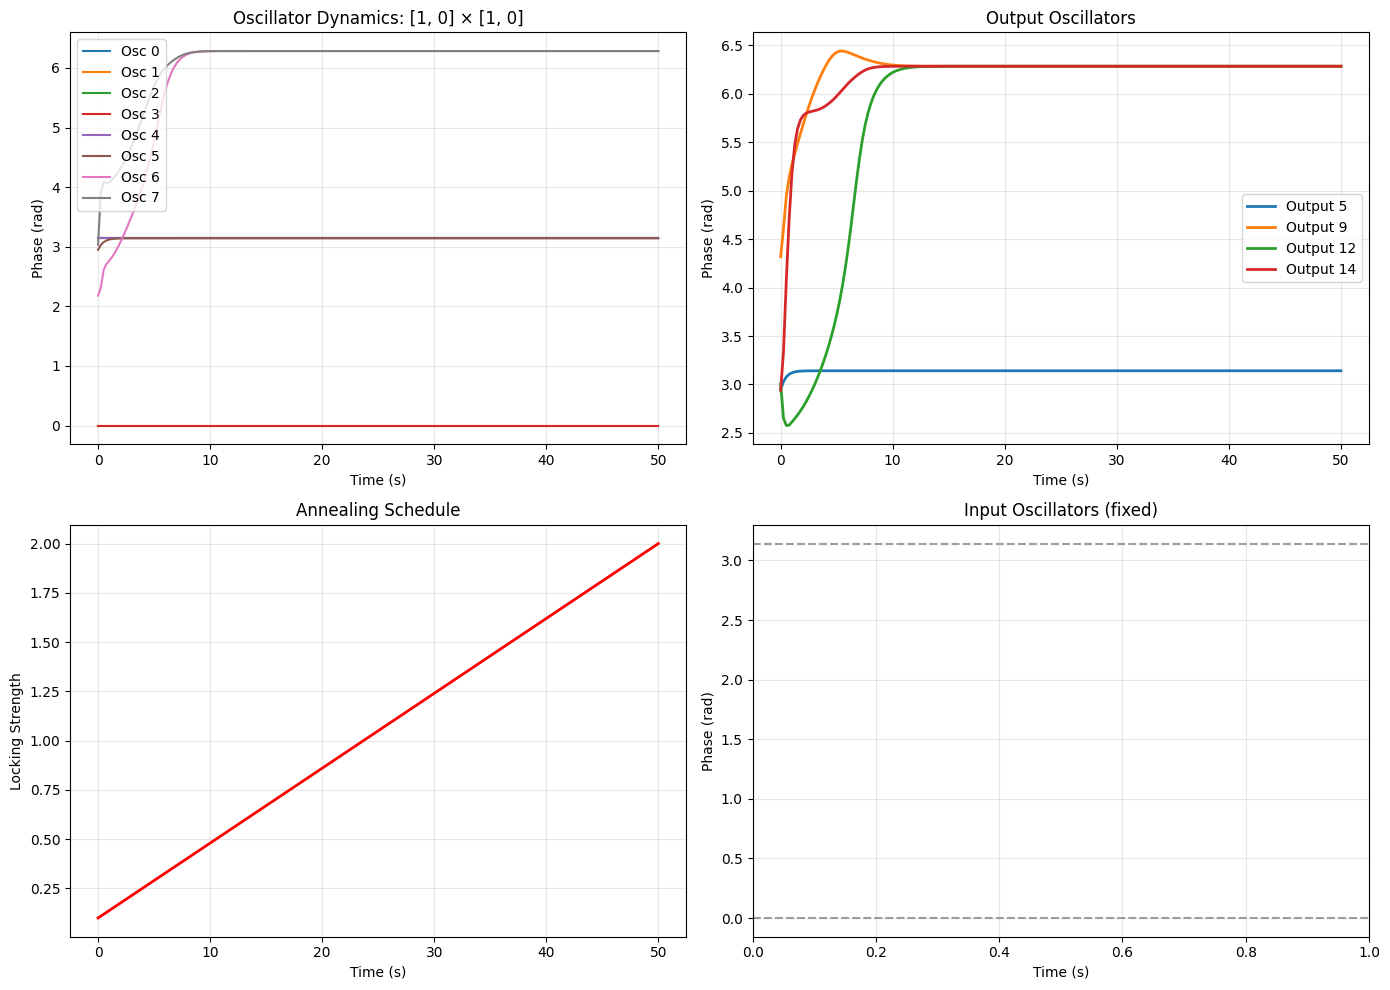


Testing forward multiplication: [1, 1] × [1, 0] = ?
A = [1, 1] (3), B = [1, 0] (1)
Expected product: [1, 1, 0, 0] (3)
Annealing: Kl 0.1 → 2 over 50s
Fixed input indices: [0, 1, 2, 3, 4]

ODE integration completed. Timepoints: 502
Final output phases (rectified): [3.14159265 3.14159265 0.         0.        ]
Output bits: [1, 1, 0, 0]
Match expected: True


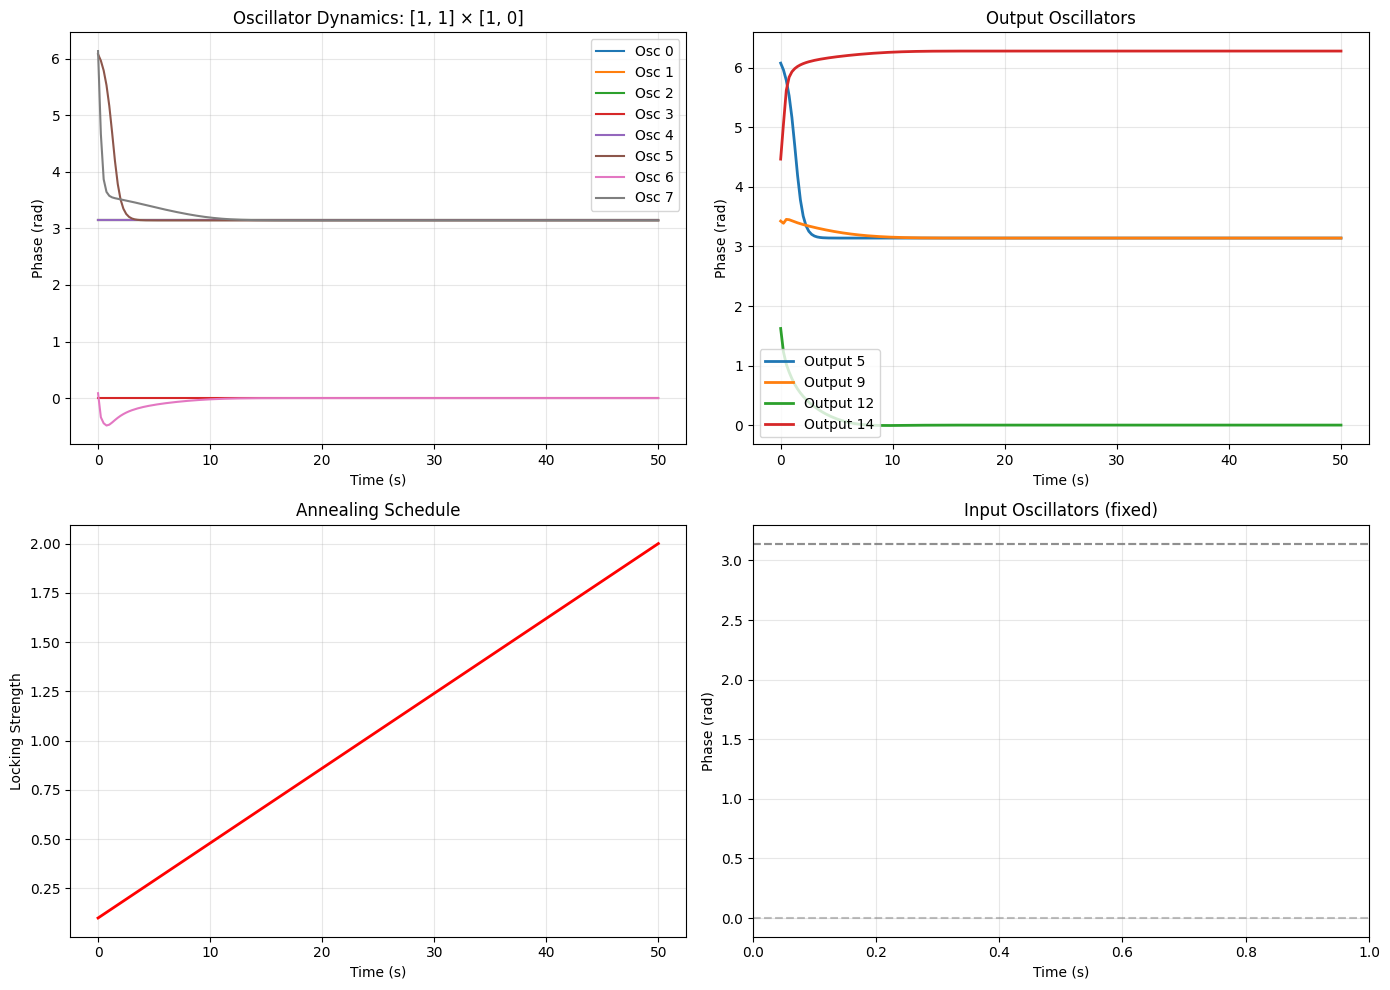


Testing forward multiplication: [1, 0] × [1, 1] = ?
A = [1, 0] (1), B = [1, 1] (3)
Expected product: [1, 1, 0, 0] (3)
Annealing: Kl 0.1 → 2 over 50s
Fixed input indices: [0, 1, 2, 3, 4]

ODE integration completed. Timepoints: 502
Final output phases (rectified): [3.14159265 3.14159265 0.         0.        ]
Output bits: [1, 1, 0, 0]
Match expected: True


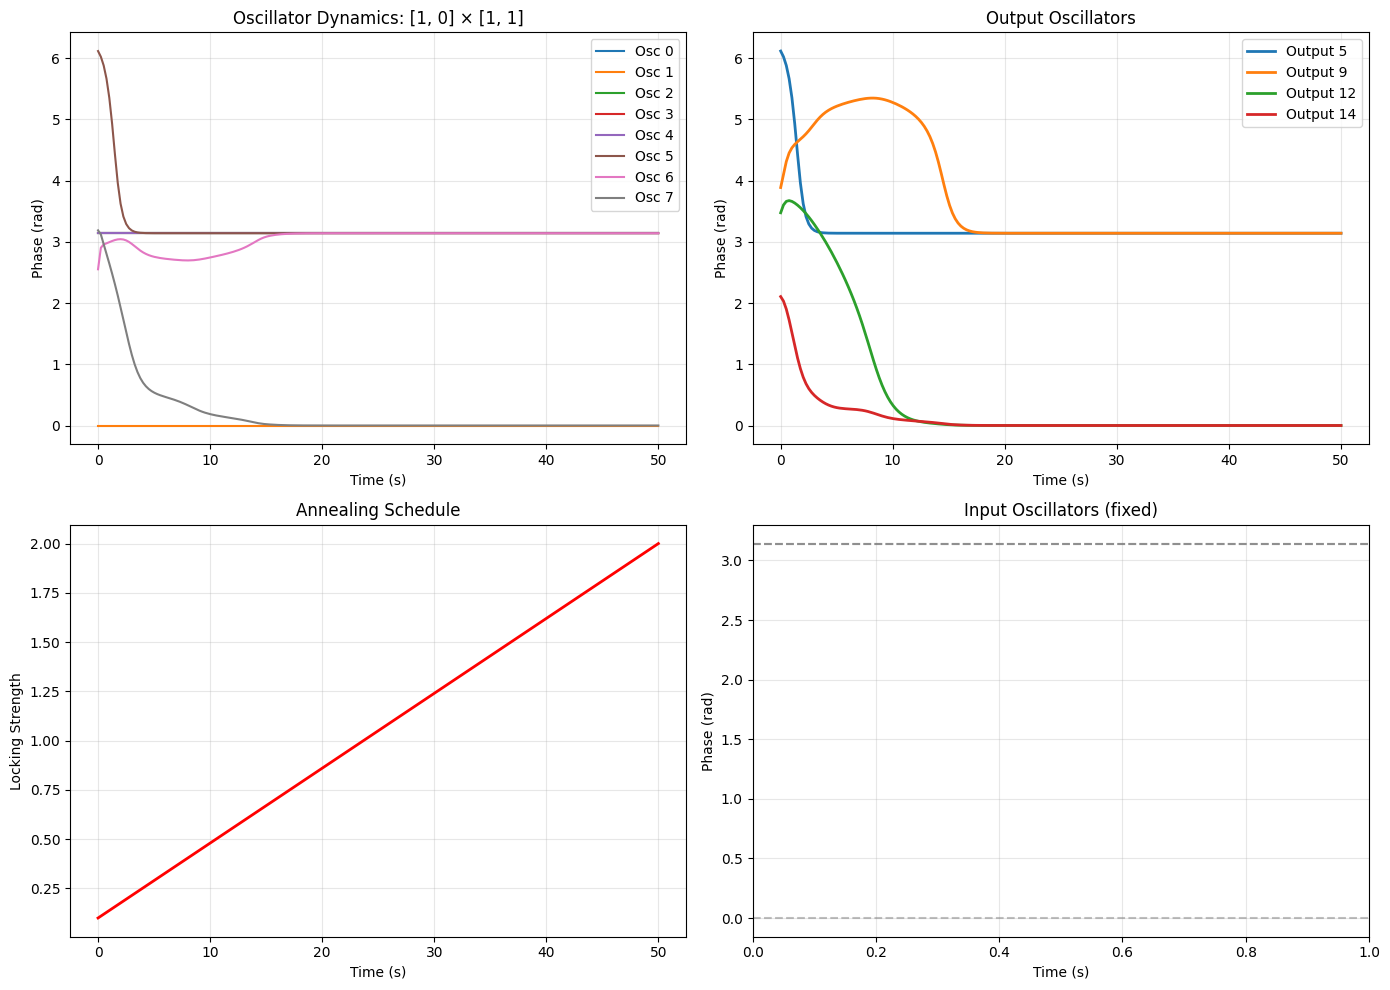

In [10]:
def kuramoto_ode_multiplier_annealed(
    t, y, J_mat, Kc=1.0, Kl_initial=1.0, Kl_final=0.1, t_total=50.0, fixed_indices=None
):
    """ODE for Kuramoto model with annealed locking strength

    Args:
        t: current time
        y: phase vector
        J_mat: coupling matrix
        Kc: coupling strength (constant)
        Kl_initial: initial locking strength
        Kl_final: final locking strength
        t_total: total simulation time for annealing schedule
        fixed_indices: indices of oscillators to keep fixed
    """
    n = len(y)
    y_diff = y[:, None] - y[None, :]
    coupling = Kc * np.sum(J_mat * np.sin(y_diff), axis=1)

    # Linear annealing schedule: Kl(t) = Kl_initial * (1 - t/t_total) + Kl_final * (t/t_total)
    progress = np.clip(t / t_total, 0.0, 1.0)
    Kl = Kl_initial * (1.0 - progress) + Kl_final * progress

    locking = Kl * np.sin(2 * y)  # Injection locking at 2x frequency
    dydt = coupling - locking

    # Zero out derivatives for fixed oscillators
    if fixed_indices is not None:
        dydt[fixed_indices] = 0.0

    return dydt


def test_forward_multiplication(
    a_bits,
    b_bits,
    osc_mult,
    t_span=(0, 50),
    Kc=1.0,
    Kl_initial=1.0,
    Kl_final=0.1,
    verbose=True,
):
    """Test forward multiplication functionality with annealed locking"""

    if verbose:
        print(f"\n{'='*60}")
        print(f"Testing forward multiplication: {a_bits} × {b_bits} = ?")
        print(f"{'='*60}")

    # Expected product
    a_int = sum(b << i for i, b in enumerate(a_bits))
    b_int = sum(b << i for i, b in enumerate(b_bits))
    product_expected = a_int * b_int
    product_bits = [(product_expected >> i) & 1 for i in range(4)]

    if verbose:
        print(f"A = {a_bits} ({a_int}), B = {b_bits} ({b_int})")
        print(f"Expected product: {product_bits} ({product_expected})")
        print(f"Annealing: Kl {Kl_initial} → {Kl_final} over {t_span[1]-t_span[0]}s")

    # Set initial conditions
    y0 = np.random.uniform(0, 2 * np.pi, size=osc_mult.n_osc_total)

    # Set input phases (these will be FIXED)
    input_indices = []
    for i, bit_val in enumerate(a_bits):
        idx = osc_mult.input_indices[f"a{i}"]
        y0[idx] = bit_val * np.pi
        input_indices.append(idx)

    for i, bit_val in enumerate(b_bits):
        idx = osc_mult.input_indices[f"b{i}"]
        y0[idx] = bit_val * np.pi
        input_indices.append(idx)

    # Set reference oscillator to fixed phase
    y0[osc_mult.ref_idx] = np.pi
    input_indices.append(osc_mult.ref_idx)

    if verbose:
        print(f"Fixed input indices: {input_indices}")

    # Solve ODE with annealed locking
    sol = solve_ivp(
        kuramoto_ode_multiplier_annealed,
        t_span,
        y0,
        args=(
            osc_mult.J_full,
            Kc,
            Kl_initial,
            Kl_final,
            t_span[1] - t_span[0],
            input_indices,
        ),
        dense_output=True,
        max_step=0.1,
    )

    if verbose:
        print(f"\nODE integration completed. Timepoints: {len(sol.t)}")

    # Extract final state and rectify
    final_state = sol.y[:, -1]
    final_rectified = rectify_phases(final_state, super_harmonic=2)

    # Extract output bits from partial products and final outputs
    output_indices = [
        osc_mult.osc_names["p0"],  # pp00 is p0
        osc_mult.osc_names["p1"],  # XOR result
        osc_mult.osc_names["p2"],  # XOR result
        osc_mult.osc_names["p3"],  # AND result
    ]

    # Convert to numpy for indexing (JAX arrays don't support list indexing)
    final_rectified_np = np.array(final_rectified)
    output_phases = final_rectified_np[output_indices]
    output_bits = [int(np.round(p / np.pi)) for p in output_phases]

    if verbose:
        print(f"Final output phases (rectified): {output_phases}")
        print(f"Output bits: {output_bits}")
        print(f"Match expected: {output_bits == product_bits}")

    # Plot trajectory
    t_plot = np.linspace(t_span[0], t_span[1], 200)
    y_plot = sol.sol(t_plot)

    # Calculate annealing schedule for plotting
    progress_plot = np.clip(t_plot / (t_span[1] - t_span[0]), 0.0, 1.0)
    Kl_plot = Kl_initial * (1.0 - progress_plot) + Kl_final * progress_plot

    plt.figure(figsize=(14, 10))

    plt.subplot(2, 2, 1)
    for i in range(min(8, osc_mult.n_osc_total)):
        plt.plot(t_plot, y_plot[i], label=f"Osc {i}")
    plt.xlabel("Time (s)")
    plt.ylabel("Phase (rad)")
    plt.title(f"Oscillator Dynamics: {a_bits} × {b_bits}")
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(2, 2, 2)
    for i in output_indices:
        plt.plot(t_plot, y_plot[i], linewidth=2, label=f"Output {i}")
    plt.xlabel("Time (s)")
    plt.ylabel("Phase (rad)")
    plt.title("Output Oscillators")
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(2, 2, 3)
    plt.plot(t_plot, Kl_plot, "r-", linewidth=2)
    plt.xlabel("Time (s)")
    plt.ylabel("Locking Strength")
    plt.title("Annealing Schedule")
    plt.grid(True, alpha=0.3)

    plt.subplot(2, 2, 4)
    for i in input_indices[:-1]:  # Exclude reference for clarity
        plt.axhline(y=y0[i], color="gray", linestyle="--", alpha=0.5)
    plt.xlabel("Time (s)")
    plt.ylabel("Phase (rad)")
    plt.title("Input Oscillators (fixed)")
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    return {
        "a": a_int,
        "b": b_int,
        "expected": product_expected,
        "computed": output_bits,
        "success": output_bits == product_bits,
        "solution": sol,
    }


# Test several multiplication cases
print("Testing forward multiplication with annealed locking...")
test_cases = [
    ([0, 0], [0, 0]),  # 0 × 0 = 0
    ([1, 0], [1, 0]),  # 1 × 1 = 1
    ([1, 1], [1, 0]),  # 3 × 1 = 3
    ([1, 0], [1, 1]),  # 2 × 3 = 6
]

forward_results = []
for a_bits, b_bits in test_cases:
    result = test_forward_multiplication(
        a_bits,
        b_bits,
        osc_mult,
        t_span=(0, 50),
        Kc=1.0,
        Kl_initial=0.1,
        Kl_final=2,
        verbose=True,
    )
    forward_results.append(result)

## 6. Test Backward Functionality with Prime Factorization

Test factorization: Given a product that's a semiprime (product of two primes), verify input oscillators converge to the two prime factors.


Testing backward factorization: 3 = ? × ?
Expected: 3 = 1 × 3
Product bits: [1, 1, 0, 0]
Fixed output indices: [5, 9, 12, 14, 4]
Annealing: Kl 0.1 → 2 over 100s
ODE integration completed. Timepoints: 1002
Input bits (a0, a1, b0, b1): [1, 1, 1, 0]
Recovered factors: 3 × 1
Match expected: True


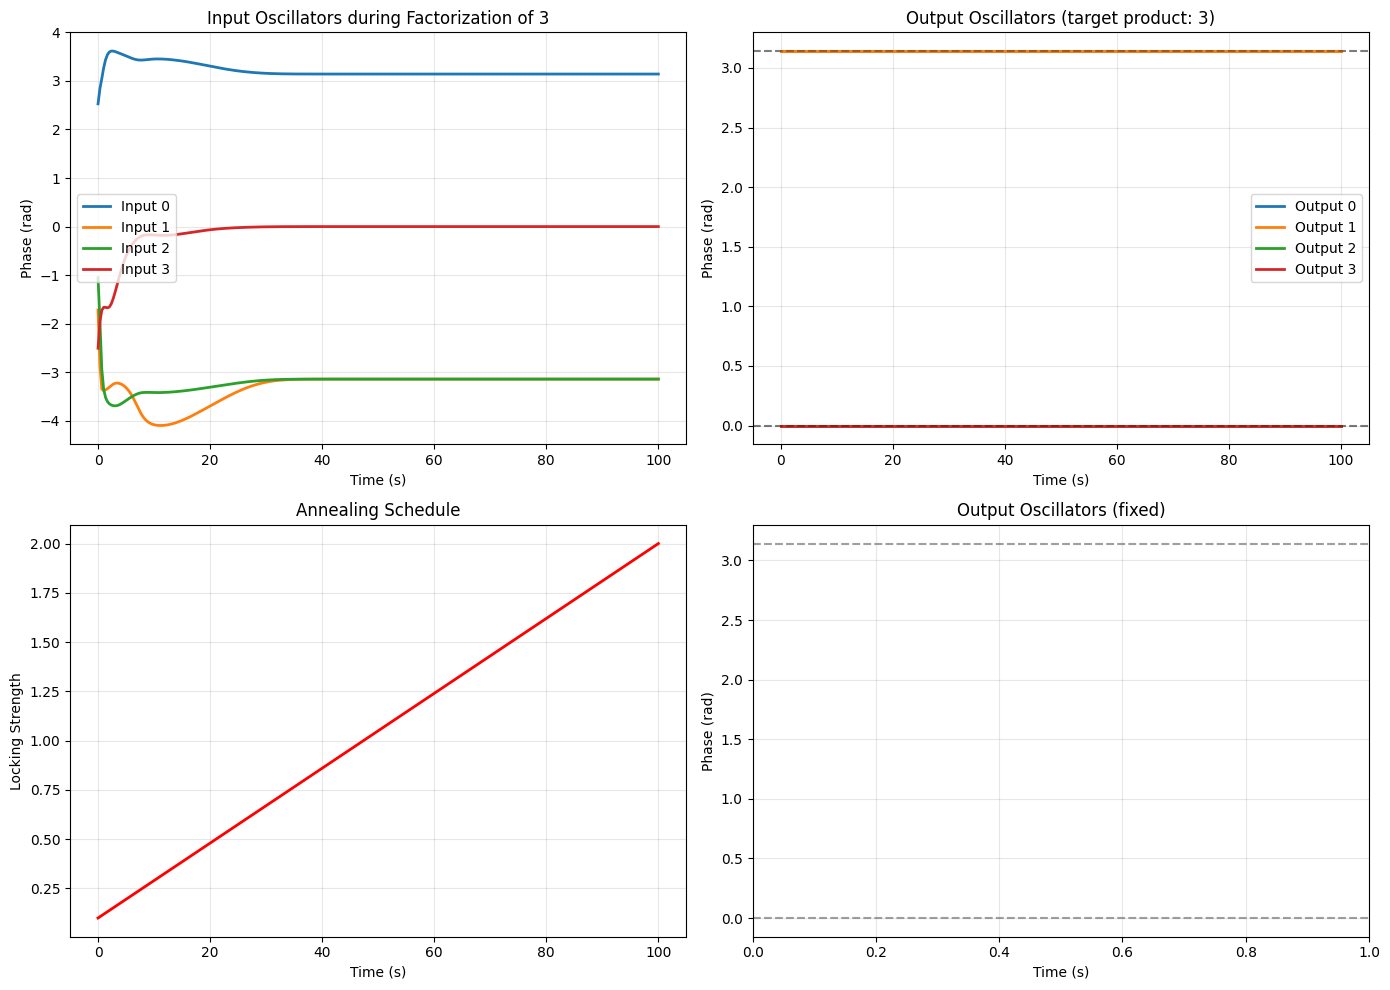


Testing backward factorization: 4 = ? × ?
Expected: 4 = 2 × 2
Product bits: [0, 0, 1, 0]
Fixed output indices: [5, 9, 12, 14, 4]
Annealing: Kl 0.1 → 2 over 100s
ODE integration completed. Timepoints: 1002
Input bits (a0, a1, b0, b1): [0, 1, 0, 1]
Recovered factors: 2 × 2
Match expected: True


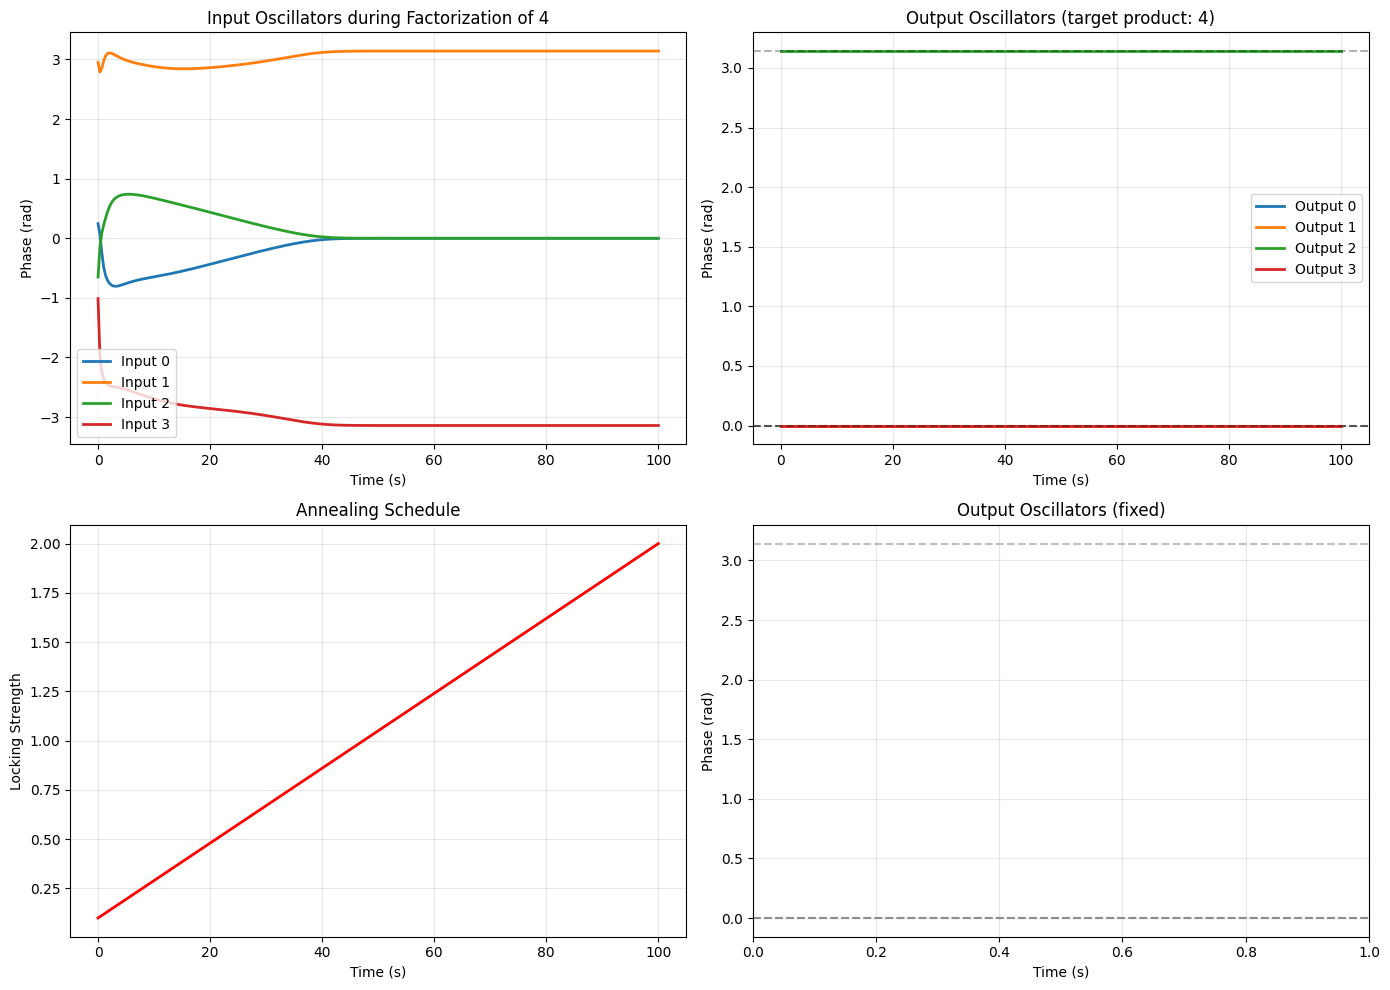


Testing backward factorization: 6 = ? × ?
Expected: 6 = 2 × 3
Product bits: [0, 1, 1, 0]
Fixed output indices: [5, 9, 12, 14, 4]
Annealing: Kl 0.1 → 2 over 100s
ODE integration completed. Timepoints: 1002
Input bits (a0, a1, b0, b1): [0, 1, 1, 1]
Recovered factors: 2 × 3
Match expected: True


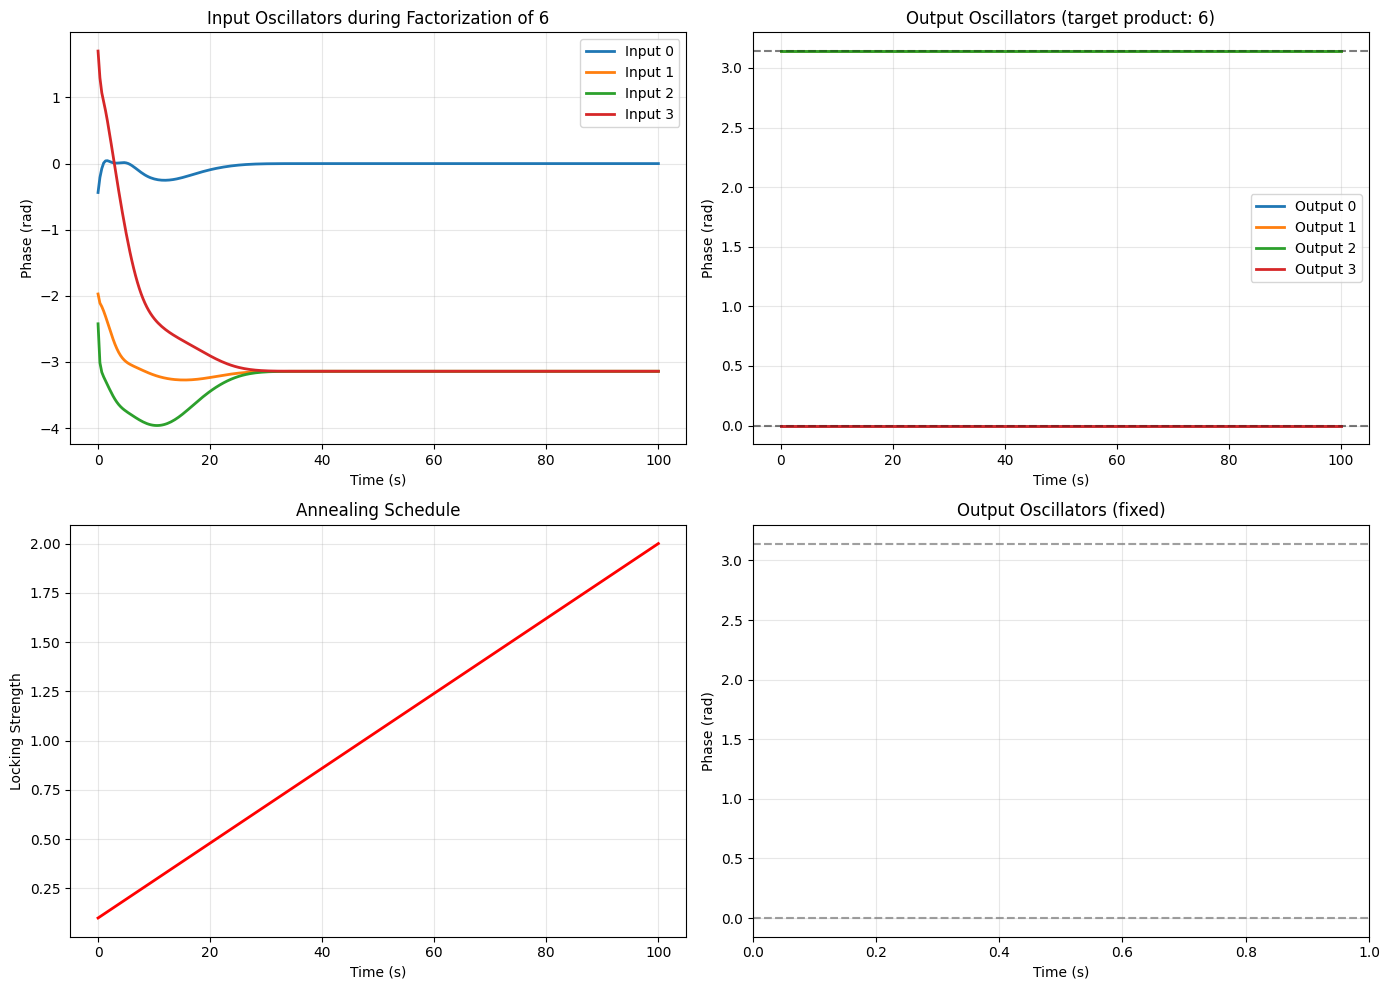

In [ ]:
def test_backward_factorization(
    product,
    expected_factors,
    osc_mult,
    t_span=(0, 100),
    Kc=1.0,
    Kl_initial=1.0,
    Kl_final=0.1,
    verbose=True,
):
    """Test backward factorization functionality with annealed locking

    Args:
        product: Target product (semiprime)
        expected_factors: Expected [factor1, factor2]
        osc_mult: OscillatorMultiplier instance
        t_span: Time span for simulation
        Kc: Coupling strength
        Kl_initial: Initial locking strength
        Kl_final: Final locking strength
        verbose: Print details
    """

    if verbose:
        print(f"\n{'='*60}")
        print(f"Testing backward factorization: {product} = ? × ?")
        print(f"Expected: {product} = {expected_factors[0]} × {expected_factors[1]}")
        print(f"{'='*60}")

    # Convert product to 4-bit representation
    product_bits = [(product >> i) & 1 for i in range(4)]

    # Initialize with random input phases
    y0 = np.random.uniform(-np.pi, np.pi, osc_mult.n_osc_total)

    # Set output phases to represent the product (FIXED during evolution)
    output_osc_names = ["p0", "p1", "p2", "p3"]
    output_indices = []
    for i, bit_val in enumerate(product_bits):
        idx = osc_mult.osc_names[output_osc_names[i]]
        y0[idx] = bit_val * np.pi
        output_indices.append(idx)

    # Also fix reference oscillator
    y0[osc_mult.ref_idx] = np.pi
    output_indices.append(osc_mult.ref_idx)

    if verbose:
        print(f"Product bits: {product_bits}")
        print(f"Fixed output indices: {output_indices}")
        print(f"Annealing: Kl {Kl_initial} → {Kl_final} over {t_span[1]-t_span[0]}s")

    # Solve ODE with fixed outputs and annealed locking
    sol = solve_ivp(
        kuramoto_ode_multiplier_annealed,
        t_span,
        y0,
        args=(
            osc_mult.J_full,
            Kc,
            Kl_initial,
            Kl_final,
            t_span[1] - t_span[0],
            output_indices,
        ),
        dense_output=True,
        max_step=0.1,
        method="RK45",
    )

    if verbose:
        print(f"ODE integration completed. Timepoints: {len(sol.t)}")

    # Extract final state and rectify
    final_state = sol.y[:, -1]
    final_rectified = rectify_phases(final_state, super_harmonic=2)

    # Extract input bits
    final_rectified_np = np.array(final_rectified)
    input_indices_extract = [0, 1, 2, 3]  # a0, a1, b0, b1
    input_phases = final_rectified_np[input_indices_extract]
    input_bits = [int(np.round(p / np.pi)) for p in input_phases]

    # Parse back to factors
    factor_a = sum(b << i for i, b in enumerate(input_bits[:2]))
    factor_b = sum(b << i for i, b in enumerate(input_bits[2:]))

    # Check if any permutation matches
    success = (factor_a == expected_factors[0] and factor_b == expected_factors[1]) or (
        factor_a == expected_factors[1] and factor_b == expected_factors[0]
    )

    if verbose:
        print(f"Input bits (a0, a1, b0, b1): {input_bits}")
        print(f"Recovered factors: {factor_a} × {factor_b}")
        print(f"Match expected: {success}")

    # Plot trajectory
    t_plot = np.linspace(t_span[0], t_span[1], 300)
    y_plot = sol.sol(t_plot)

    # Calculate annealing schedule for plotting
    progress_plot = np.clip(t_plot / (t_span[1] - t_span[0]), 0.0, 1.0)
    Kl_plot = Kl_initial * (1.0 - progress_plot) + Kl_final * progress_plot

    plt.figure(figsize=(14, 10))

    plt.subplot(2, 2, 1)
    input_idx_plot = [
        osc_mult.input_indices["a0"],
        osc_mult.input_indices["a1"],
        osc_mult.input_indices["b0"],
        osc_mult.input_indices["b1"],
    ]
    for i in input_idx_plot:
        plt.plot(t_plot, y_plot[i], label=f"Input {i}", linewidth=2)
    plt.xlabel("Time (s)")
    plt.ylabel("Phase (rad)")
    plt.title(f"Input Oscillators during Factorization of {product}")
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(2, 2, 2)
    output_idx_plot = [osc_mult.osc_names[name] for name in output_osc_names]
    for i, idx in enumerate(output_idx_plot):
        target_phase = product_bits[i] * np.pi
        plt.plot(t_plot, y_plot[idx], label=f"Output {i}", linewidth=2)
        plt.axhline(y=target_phase, color="k", linestyle="--", alpha=0.3)
    plt.xlabel("Time (s)")
    plt.ylabel("Phase (rad)")
    plt.title(f"Output Oscillators (target product: {product})")
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(2, 2, 3)
    plt.plot(t_plot, Kl_plot, "r-", linewidth=2)
    plt.xlabel("Time (s)")
    plt.ylabel("Locking Strength")
    plt.title("Annealing Schedule")
    plt.grid(True, alpha=0.3)

    plt.subplot(2, 2, 4)
    for i in output_indices[:-1]:  # Exclude reference for clarity
        plt.axhline(y=y0[i], color="gray", linestyle="--", alpha=0.5)
    plt.xlabel("Time (s)")
    plt.ylabel("Phase (rad)")
    plt.title("Output Oscillators (fixed)")
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    return {
        "product": product,
        "expected": expected_factors,
        "computed": [factor_a, factor_b],
        "success": success,
        "solution": sol,
        "input_bits": input_bits,
    }


# Test prime factorization cases
# Using products of two small primes that fit in 2-bit operands
semiprime_cases = [
    (3, [1, 3]),  # 3 = 1 × 3
    (4, [2, 2]),  # 4 = 2 × 2
    (6, [2, 3]),  # 6 = 2 × 3
]

backward_results = []
for product, expected_factors in semiprime_cases:
    if product <= 9:  # Ensure it fits in 4-bit output
        result = test_backward_factorization(
            product,
            expected_factors,
            osc_mult,
            t_span=(0, 100),
            Kc=1.0,
            Kl_initial=0.1,
            Kl_final=2,
            verbose=True,
        )
        backward_results.append(result)

## Summary: Oscillator-Based Multiplier with Shared Reference and Output Reuse

This notebook demonstrates key principles for composing oscillator-based logic circuits:

### Key Design Improvements:
1. **Shared Reference Oscillator**: All gates use a single shared reference oscillator at a fixed phase (π), reducing oscillator count significantly
2. **Output Reuse**: Output oscillators of one gate serve as inputs to subsequent gates, enabling circuit composition without duplication
3. **Flexible Gate Catalog**: Any 2-input-1-output logic gate (AND, OR, XOR, NAND, NOR, etc.) can be used as needed

### Results:
The following cells show the forward and backward test results.

In [8]:
print("=" * 70)
print("FORWARD MULTIPLICATION TEST RESULTS")
print("=" * 70)
for i, result in enumerate(forward_results):
    status = "✓ PASS" if result["success"] else "✗ FAIL"
    print(
        f"\nTest {i+1}: {result['a']} × {result['b']} = {result['expected']} {status}"
    )
    print(f"  Expected bits: {result['expected']}")
    print(f"  Computed bits: {result['computed']}")

print("\n" + "=" * 70)
print("BACKWARD FACTORIZATION TEST RESULTS")
print("=" * 70)
for i, result in enumerate(backward_results):
    status = "✓ PASS" if result["success"] else "✗ FAIL"
    print(f"\nTest {i+1}: Factorize {result['product']} {status}")
    print(
        f"  Expected: {result['product']} = {result['expected'][0]} × {result['expected'][1]}"
    )
    print(
        f"  Computed: {result['product']} = {result['computed'][0]} × {result['computed'][1]}"
    )

# Summary statistics
forward_pass = sum(1 for r in forward_results if r["success"])
backward_pass = sum(1 for r in backward_results if r["success"])

print("\n" + "=" * 70)
print(f"SUMMARY")
print("=" * 70)
print(f"Forward tests:  {forward_pass}/{len(forward_results)} passed")
print(f"Backward tests: {backward_pass}/{len(backward_results)} passed")
print(
    f"Overall: {forward_pass + backward_pass}/{len(forward_results) + len(backward_results)} passed"
)

FORWARD MULTIPLICATION TEST RESULTS

Test 1: 0 × 0 = 0 ✓ PASS
  Expected bits: 0
  Computed bits: [0, 0, 0, 0]

Test 2: 1 × 1 = 1 ✗ FAIL
  Expected bits: 1
  Computed bits: [0, 0, 0, 0]

Test 3: 3 × 1 = 3 ✗ FAIL
  Expected bits: 3
  Computed bits: [0, 0, 0, 0]

Test 4: 1 × 3 = 3 ✗ FAIL
  Expected bits: 3
  Computed bits: [0, 0, 0, 0]

BACKWARD FACTORIZATION TEST RESULTS

Test 1: Factorize 3 ✓ PASS
  Expected: 3 = 1 × 3
  Computed: 3 = 1 × 3

Test 2: Factorize 4 ✗ FAIL
  Expected: 4 = 2 × 2
  Computed: 4 = 0 × 0

Test 3: Factorize 6 ✓ PASS
  Expected: 6 = 2 × 3
  Computed: 6 = 3 × 2

SUMMARY
Forward tests:  1/4 passed
Backward tests: 2/3 passed
Overall: 3/7 passed
